In [217]:
import pandas as pd
from pathlib import Path
import glob
import json

import matplotlib.pyplot as plt

In [218]:
#SOURCES_TO_COMPARE = ["random_control", "hard_coded_control", "baseline", "comfort_band", "scaled_comfort", "comfort_band_hold_1h", "comfort_band_hold_2_5h"]
SOURCES_TO_COMPARE = ["random_control", "hard_coded_control", "drl_baseline", "drl_ambient_adjusted", "drl_ambient_adjusted_new"] #, "drl_ambient_adjusted_hold_5", "drl_ambient_adjusted_hold_10", "drl_ambient_adjusted_hold_15"]

name_to_short_label = {
    "random_control": "Random",
    "hard_coded_control": "Rule-based",
    "drl_baseline": "DRL (baseline reward)",
    "drl_baseline_new": "DRL baseline\n(new)",
    "drl_ambient_adjusted": "DRL (adjusted reward)",
    "drl_ambient_adjusted_new": "DRL ambient adjusted\n(new)",
}

CONTROL_ACTIONS = {
    "all_closed": 0, # for winter night
    "all_open": 2, # for summer night
    "inside_open": 1, # for winter day (with radiation)
    "outside_open": -1 # for summer day
}

# T_HIGH = 24.0
# T_LOW = 20.0
# T_MID = (T_HIGH + T_LOW) / 2

In [219]:
def din_comfort_band(ambient_temp):
    if ambient_temp < 16:
        return (20, 22, 24)
    elif ambient_temp < 32:
        return (16 + 0.25 * ambient_temp, 18 + 0.25 * ambient_temp, 20 + 0.25 * ambient_temp)
    else:
        return (24, 26, 28)

def inside_comfort_band(ambient_temp, operative_temp):
    lower, mid, upper = din_comfort_band(ambient_temp)
    if lower <= operative_temp <= upper:
        return True
    else:
        return False

def overheating_hours(ambient_temp, operative_temp):
    lower, mid, upper = din_comfort_band(ambient_temp)
    if operative_temp > upper:
        return operative_temp - upper
    else:
        return 0

def undercooling_hours(ambient_temp, operative_temp):
    lower, mid, upper = din_comfort_band(ambient_temp)
    if operative_temp < lower:
        return lower - operative_temp
    else:
        return 0

In [220]:
RESULTS_PATH = Path(r"C:\Users\lkclu\Documents\GitHub\DTFS\results\control\simulation_test_setup_4")

records_by_source = {}
for source_path in RESULTS_PATH.iterdir():
    if not source_path.is_dir():
        continue
    records = []
    for file_path in source_path.glob("*.jsonl"):
        with open(file_path, encoding="utf-8") as file:
            records.extend(json.loads(line) for line in file if line.strip())
    if records:
        frame = pd.json_normalize(records)
        frame["source"] = source_path.name
        records_by_source[source_path.name] = frame

if not records_by_source:
    raise FileNotFoundError(f"No JSONL result files found in {RESULTS_PATH}")

data = pd.concat(records_by_source.values(), ignore_index=True)
data.columns = [column.split(".")[-1] for column in data.columns]

start_date = pd.Timestamp("2024-01-01")
data["datetime"] = start_date + pd.to_timedelta(data["current_time"], unit="h")
data = data[data["source"].isin(SOURCES_TO_COMPARE)]
data[["t_low", "t_mid", "t_high"]] = data["dry_bulb_temperature"].apply(
    lambda t: pd.Series(din_comfort_band(t))
)
data["inside_comfort"] = data.apply(
    lambda row: inside_comfort_band(row["dry_bulb_temperature"], row["operative_temperature"]), axis=1
)

data["overheating"] = data.apply(
    lambda row: overheating_hours(row["dry_bulb_temperature"], row["operative_temperature"]), axis=1
)

data["undercooling"] = data.apply(
    lambda row: undercooling_hours(row["dry_bulb_temperature"], row["operative_temperature"]), axis=1
)

In [221]:
data.head()

,control,hour_of_day,current_time,dry_bulb_temperature,total_horizontal_radiation,operative_temperature,source,datetime,t_low,t_mid,t_high,inside_comfort,overheating,undercooling
0,-1,0.0,0.166667,15.0,0.0,22.140978,drl_ambient_adjusted,2024-01-01 00:10:00.000000001,20.0,22.0,24.0,True,0.0,0.0
1,-1,0.0,0.333333,15.0,0.0,22.387765,drl_ambient_adjusted,2024-01-01 00:19:59.999999998,20.0,22.0,24.0,True,0.0,0.0
2,-1,0.0,0.500000,15.0,0.0,22.572968,drl_ambient_adjusted,2024-01-01 00:30:00.000000000,20.0,22.0,24.0,True,0.0,0.0
3,-1,0.0,0.666667,15.0,0.0,22.711896,drl_ambient_adjusted,2024-01-01 00:40:00.000000001,20.0,22.0,24.0,True,0.0,0.0
4,-1,0.0,0.833333,15.0,0.0,22.816046,drl_ambient_adjusted,2024-01-01 00:49:59.999999998,20.0,22.0,24.0,True,0.0,0.0


In [222]:
# WEEK_NUMBER = 95

# week_length = 24*3

# week_interval = ((WEEK_NUMBER - 1) * week_length, WEEK_NUMBER * week_length)

# print(week_interval)

# filtered_data = data[(data['current_time'] >= week_interval[0]) & (data['current_time'] < week_interval[1])]

# filtered_data.head()


In [223]:
filtered_data = data

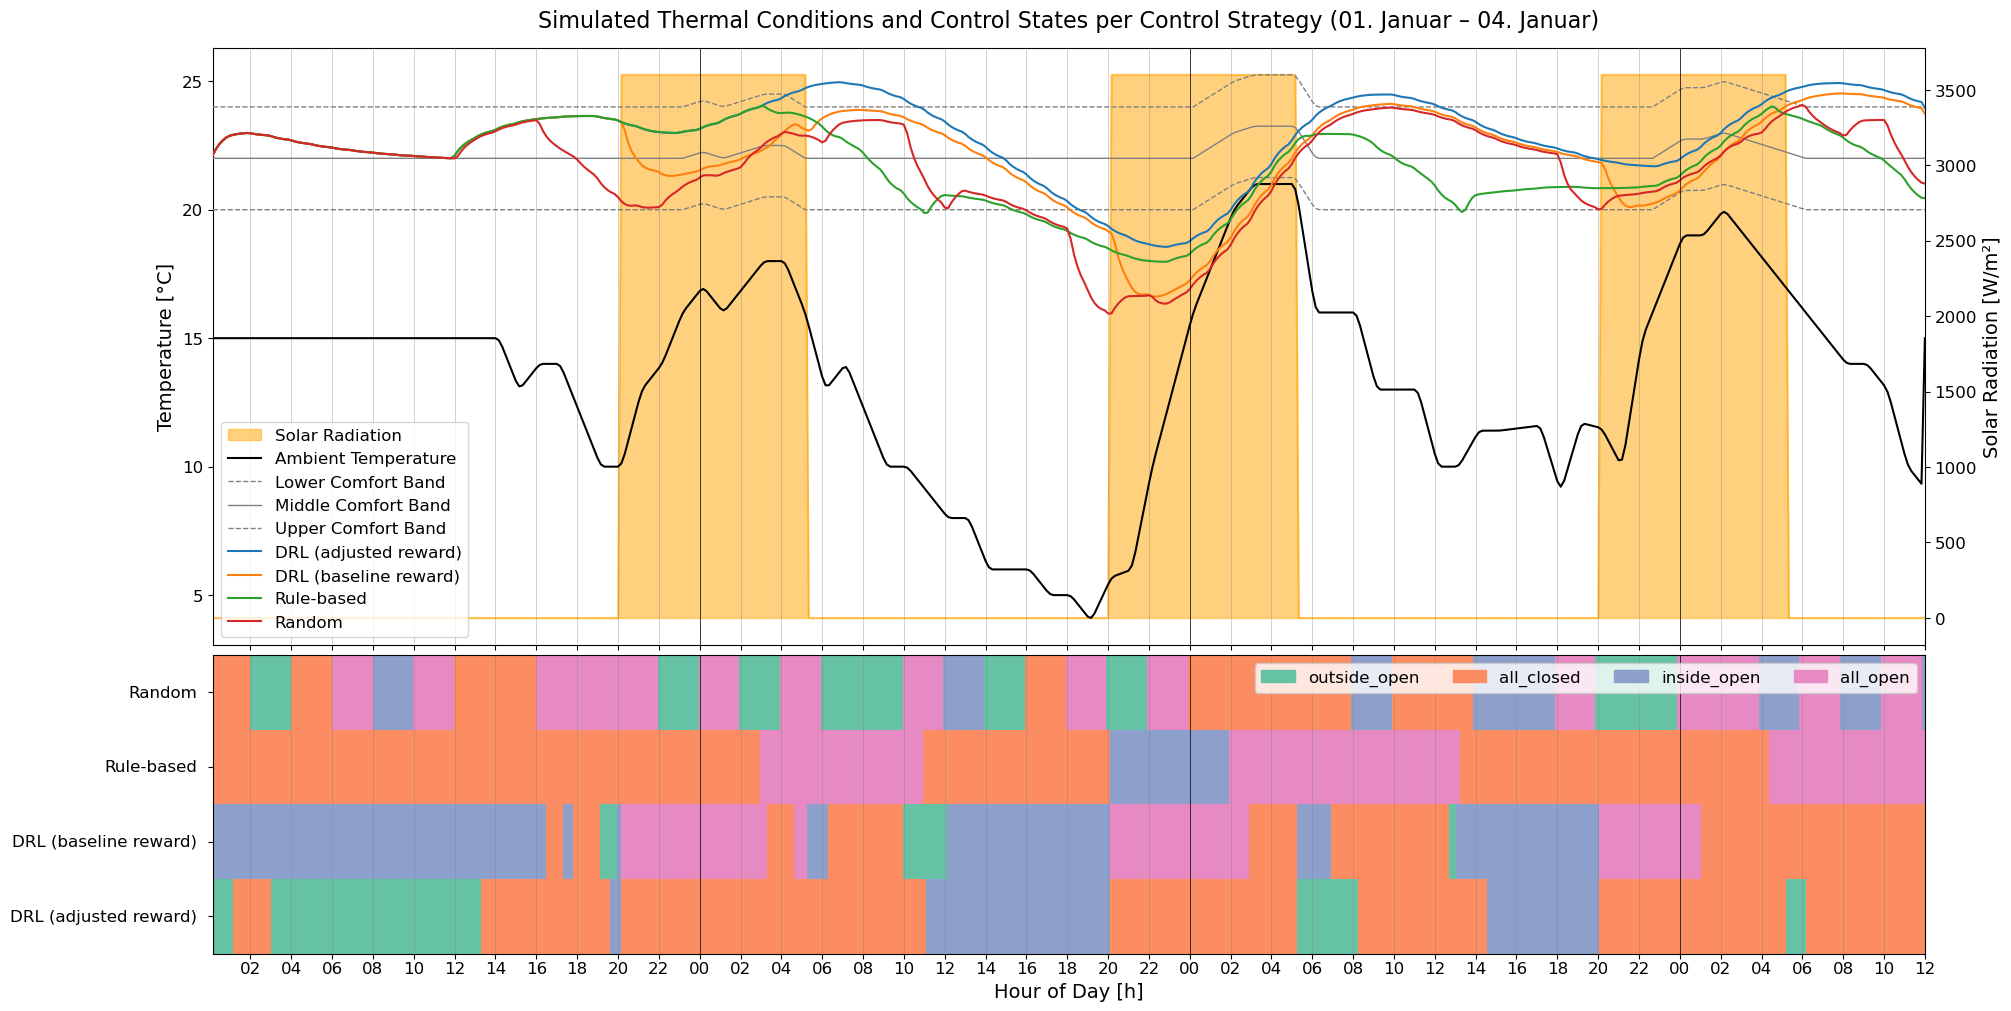

In [224]:
import matplotlib.dates as mdates
import matplotlib.transforms as transforms
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import locale

locale.setlocale(locale.LC_TIME, "de_DE.UTF-8")

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10), sharex=True, constrained_layout=True, gridspec_kw={"height_ratios": [2, 1]})
ax1_rad = ax1.twinx()

# Plot dry bulb once
first_source = filtered_data['source'].unique()[0]
filtered_data[filtered_data['source'] == first_source].plot(
    kind="line", x="datetime", y="dry_bulb_temperature",
    ax=ax1, color="black", label="Ambient Temperature"
)

# Radiation on second y-axis (once, same across sources)
filtered_data[filtered_data['source'] == first_source].plot(
    kind="area", x="datetime", y="total_horizontal_radiation",
    ax=ax1_rad, color="orange", label="Solar Radiation", alpha=0.5
)

ax1_rad.set_zorder(ax1.get_zorder() - 1)
ax1.set_frame_on(False)

filtered_data[filtered_data['source'] == first_source].plot(
    kind="line", x="datetime", y="t_low",
    ax=ax1, color="grey", label="Lower Comfort Band", linestyle="--", linewidth=1
)

filtered_data[filtered_data['source'] == first_source].plot(
    kind="line", x="datetime", y="t_mid",
    ax=ax1, color="grey", label="Middle Comfort Band", linestyle="-", linewidth=1
)

filtered_data[filtered_data['source'] == first_source].plot(
    kind="line", x="datetime", y="t_high",
    ax=ax1, color="grey", label="Upper Comfort Band", linestyle="--", linewidth=1
)

for source, subset in filtered_data.groupby('source'):
    subset.plot(
        kind="line", x="datetime", y="operative_temperature", ax=ax1,
        label=name_to_short_label.get(source, source),
    )

ax1.set_ylabel("Temperature [°C]")
lines1, labels1 = ax1.get_legend_handles_labels()
lines_rad, labels_rad = ax1_rad.get_legend_handles_labels()
ax1.legend(lines_rad + lines1, labels_rad + labels1, loc="best")
ax1_rad.set_ylabel("Solar Radiation [W/m²]")
ax1_rad.get_legend().remove()

# --------------------------------------------------------------------------
# Control state as colored bands (one row per source)
# --------------------------------------------------------------------------
control_labels = {v: k for k, v in CONTROL_ACTIONS.items()}
state_values = sorted(control_labels.keys())
state_colors = plt.cm.Set2.colors[:len(state_values)]

cmap = mcolors.ListedColormap(state_colors)
bounds = [state_values[0] - 0.5] + [
    (state_values[i] + state_values[i + 1]) / 2 for i in range(len(state_values) - 1)
] + [state_values[-1] + 0.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

sources = filtered_data['source'].unique()

for i, source in enumerate(sources):
    subset = filtered_data[filtered_data['source'] == source].sort_values('datetime')
    t = mdates.date2num(subset['datetime'].values)
    c = subset['control'].values.reshape(1, -1)

    ax2.imshow(
        c, aspect='auto', cmap=cmap, norm=norm,
        extent=[t[0], t[-1], i, i + 1],
        interpolation='nearest',
        origin='lower'
    )

ax2.set_ylim(0, len(sources))
ax2.set_yticks([i + 0.5 for i in range(len(sources))])
ax2.set_yticklabels(
    [name_to_short_label.get(source, source) for source in sources],
    rotation=0,
    ha="right",
    va="center",
)
ax2.tick_params(axis="y", pad=8)
ax2.set_ylabel("")

# Legend built manually since imshow doesn't auto-generate one
legend_patches = [
    mpatches.Patch(color=state_colors[j], label=control_labels[val])
    for j, val in enumerate(state_values)
]
ax2.legend(handles=legend_patches, loc="upper right", ncol=len(state_values))

# Split x-axis: hours on top, days on bottom
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H"))

# Hour gridlines
ax1.xaxis.grid(True, which='major', linestyle='-', linewidth=0.5, color='gray', alpha=0.5)
ax2.xaxis.grid(True, which='major', linestyle='-', linewidth=0.5, color='gray', alpha=0.5)

# Day gridlines
day_ticks = mdates.DayLocator().tick_values(filtered_data['datetime'].min(), filtered_data['datetime'].max())
for day in day_ticks:
    ax1.axvline(mdates.num2date(day), linestyle='-', linewidth=0.5, color='black')
    ax2.axvline(mdates.num2date(day), linestyle='-', linewidth=0.5, color='black')

ax2.tick_params(axis='x', which='both', rotation=0)

# Force render first, then set minor locator/formatter
# Dates as minor ticks
ax2.xaxis.set_minor_locator(mdates.DayLocator())
ax2.xaxis.set_minor_formatter(
    mdates.DateFormatter("%d. %B")
)

# Hour labels
ax2.tick_params(
    axis="x",
    which="major",
    rotation=0,
    pad=2
)

# Date labels
ax2.tick_params(
    axis="x",
    which="minor",
    rotation=0,
    pad=18
)

for label in ax2.xaxis.get_majorticklabels():
    label.set_ha("center")

for label in ax2.xaxis.get_minorticklabels():
    label.set_ha("center")

ax2.set_xlabel("Hour of Day [h]")
ax1.set_xlabel("")

start_date = filtered_data["datetime"].min().strftime("%d. %B")
end_date = filtered_data["datetime"].max().strftime("%d. %B")

plt.title(
    f"Simulated Thermal Conditions and Control States per Control Strategy "
    f"({start_date} – {end_date})",
    y=1.02
)

plt.show()

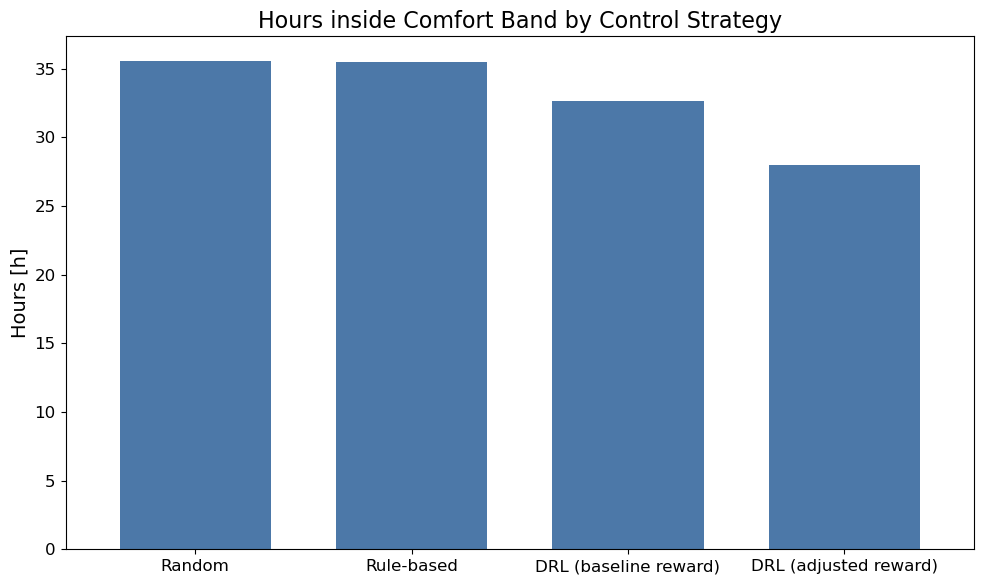

In [225]:
comfort_hours = data.groupby("source")["inside_comfort"].sum() / 12

# build clean summary dataframe
summary = pd.DataFrame({
    "Comfort hours": comfort_hours
}).reindex(SOURCES_TO_COMPARE).dropna()
summary.index = [name_to_short_label.get(source, source) for source in summary.index]

# plot
summary.plot(kind="bar", figsize=(10, 6), width=0.7, color=["#4C78A8", "#F58518", "#54A24B", "#E45756", "#B279A2", "#72B7B2", "#FF9DA6"])

plt.ylabel("Hours [h]")
plt.xlabel("")
plt.title("Hours inside Comfort Band by Control Strategy")
plt.xticks(rotation=0)
plt.legend().remove()
plt.tight_layout()
plt.show()

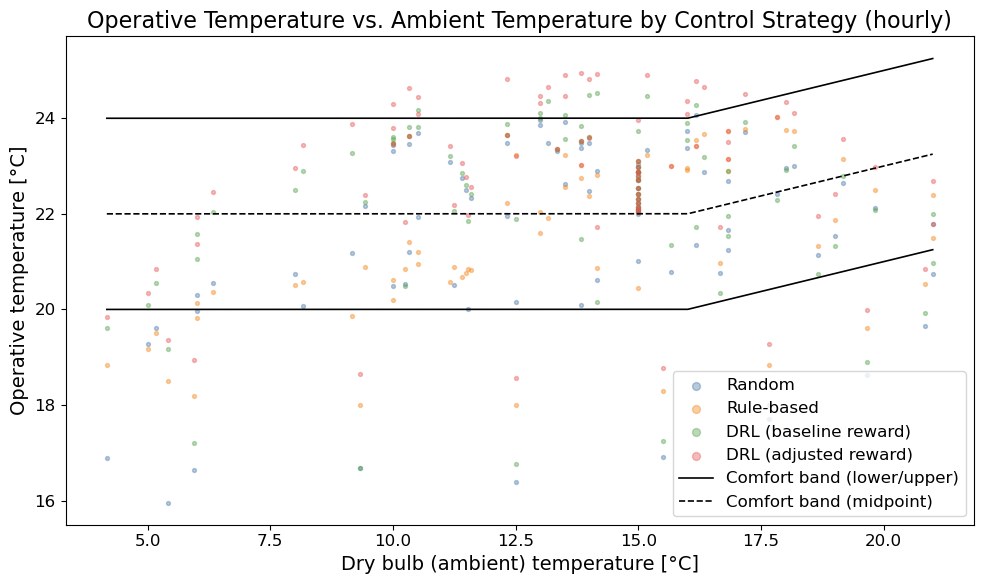

In [226]:
import numpy as np
selected_data = data[data["datetime"].dt.minute == 0]

fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]

for source, color in zip(SOURCES_TO_COMPARE, colors):
    subset = selected_data[selected_data["source"] == source]
    if subset.empty:
        continue
    label = name_to_short_label.get(source, source)
    ax.scatter(
        subset["dry_bulb_temperature"],
        subset["operative_temperature"],
        s=8,
        alpha=0.4,
        color=color,
        label=label,
    )

x_range = np.linspace(
    selected_data["dry_bulb_temperature"].min(),
    selected_data["dry_bulb_temperature"].max(),
    200,
)

lower, mid, upper = zip(*[din_comfort_band(t) for t in x_range])

ax.plot(x_range, lower, "-", color="black", linewidth=1.2, label="Comfort band (lower/upper)")
ax.plot(x_range, upper, "-", color="black", linewidth=1.2)
ax.plot(x_range, mid, "--", color="black", linewidth=1.2, label="Comfort band (midpoint)")

ax.set_xlabel("Dry bulb (ambient) temperature [°C]")
ax.set_ylabel("Operative temperature [°C]")
ax.set_title("Operative Temperature vs. Ambient Temperature by Control Strategy (hourly)")
ax.legend(title="", loc="best", markerscale=2)
plt.tight_layout()
plt.show()

2016
403


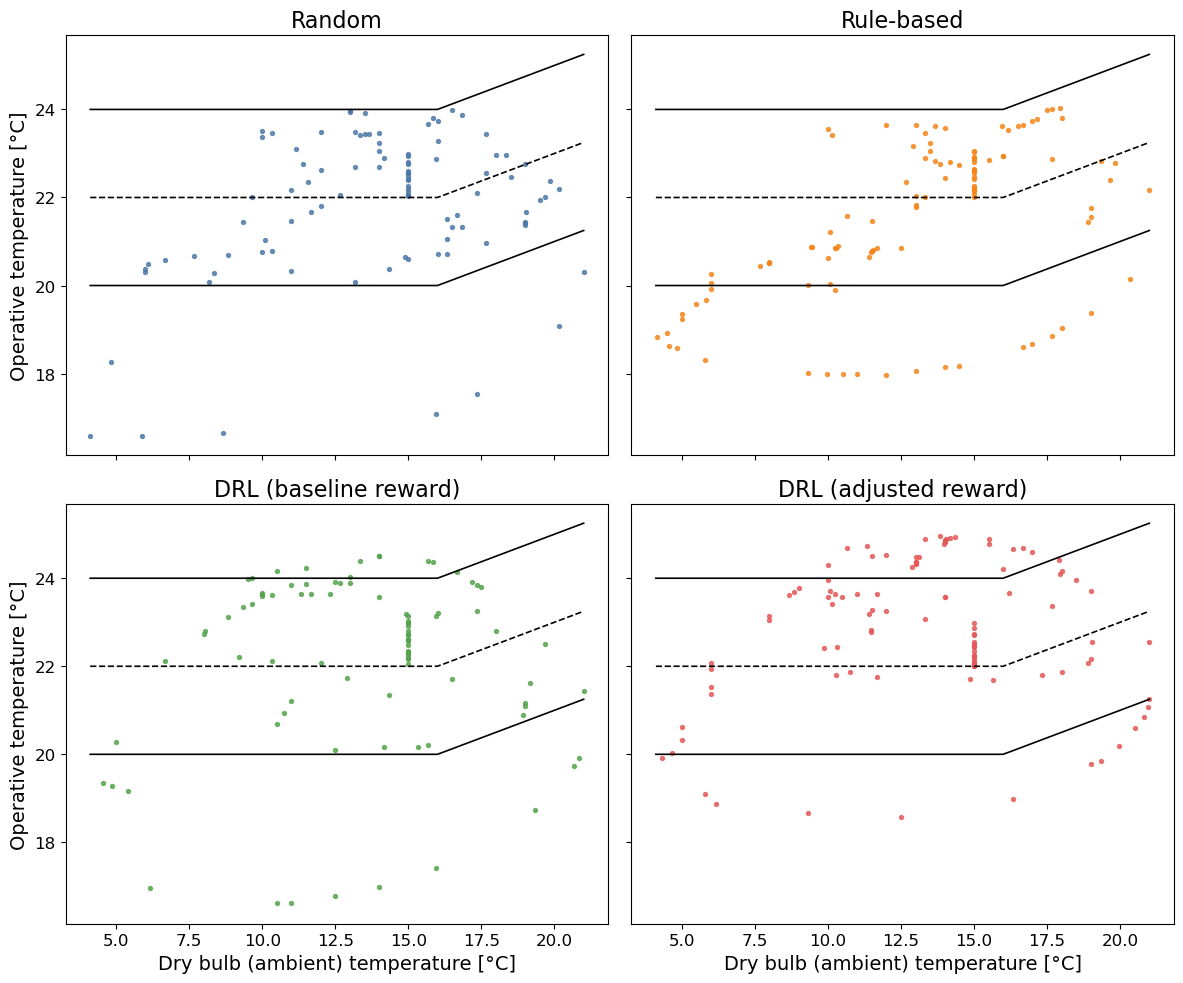

In [227]:
import numpy as np
print(len(data))
selected_data = data.sample(frac=0.2, random_state=42)  # Sample 10% of the data for faster plotting

print(len(selected_data))

colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]

x_range = np.linspace(
    selected_data["dry_bulb_temperature"].min(),
    selected_data["dry_bulb_temperature"].max(),
    200,
)
lower, mid, upper = zip(*[din_comfort_band(t) for t in x_range])

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

for ax, source, color in zip(axes.flat, SOURCES_TO_COMPARE, colors):
    subset = selected_data[selected_data["source"] == source]
    label = name_to_short_label.get(source, source)

    if not subset.empty:
        ax.scatter(
            subset["dry_bulb_temperature"],
            subset["operative_temperature"],
            s=8,
            alpha=0.8,
            color=color,
            label=label,
        )

    ax.plot(x_range, lower, "-", color="black", linewidth=1.2, label="Comfort band (lower/upper)")
    ax.plot(x_range, upper, "-", color="black", linewidth=1.2)
    ax.plot(x_range, mid, "--", color="black", linewidth=1.2, label="Comfort band (midpoint)")

    ax.set_title(label)
    # ax.legend(title="", loc="best", markerscale=2, fontsize=8)

for ax in axes[-1, :]:
    ax.set_xlabel("Dry bulb (ambient) temperature [°C]")
for ax in axes[:, 0]:
    ax.set_ylabel("Operative temperature [°C]")

#fig.suptitle("Operative Temperature vs. Ambient Temperature by Control Strategy (hourly)", y=1.02)
plt.tight_layout()
plt.show()

C:\Users\lkclu\AppData\Local\Temp\ipykernel_30300\3491605882.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")


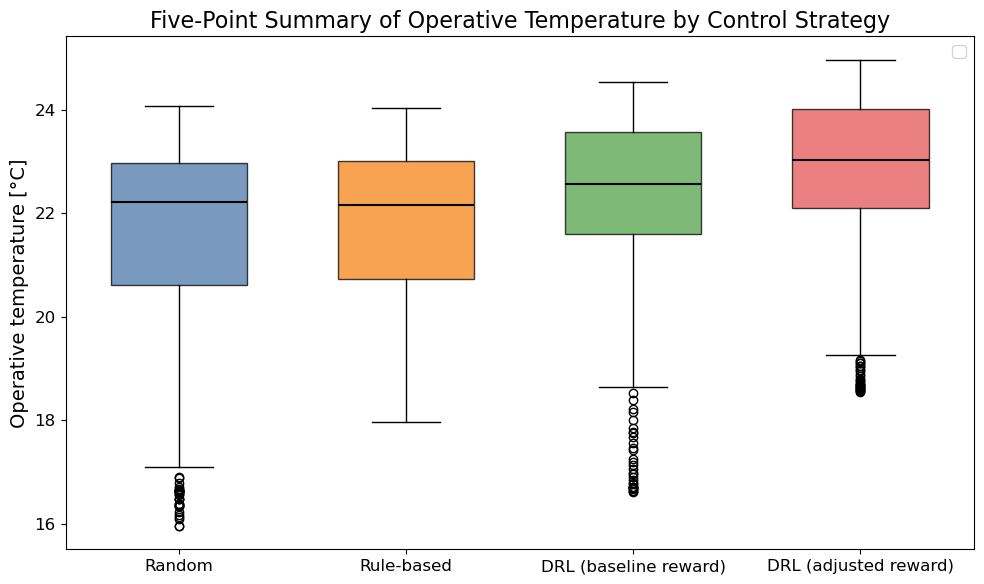

In [228]:
sources_present = [s for s in SOURCES_TO_COMPARE if s in data["source"].unique()]
labels = [name_to_short_label.get(s, s) for s in sources_present]

# collect operative_temperature values per source, in the same order
box_data = [
    data.loc[data["source"] == source, "operative_temperature"].dropna().values
    for source in sources_present
]

fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#B279A2", "#72B7B2", "#FF9DA6"]

bp = ax.boxplot(
    box_data,
    tick_labels=labels,
    patch_artist=True,      # allows filling boxes with color
    widths=0.6,
    showfliers=True,        # set False if you'd rather hide outlier points
    medianprops=dict(color="black", linewidth=1.5),
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_ylabel("Operative temperature [°C]")
ax.set_xlabel("")
ax.set_title("Five-Point Summary of Operative Temperature by Control Strategy")
ax.legend(loc="upper right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

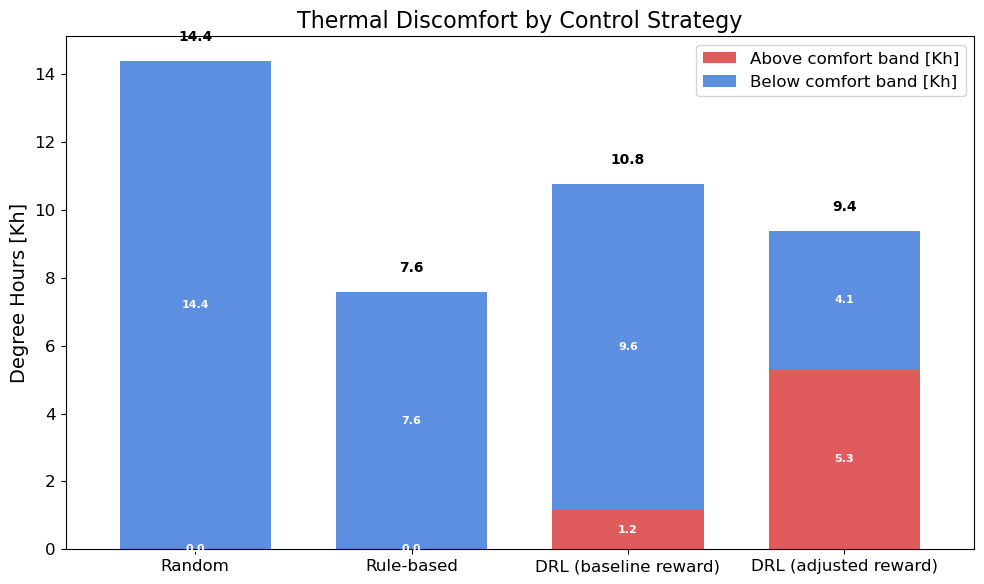

In [229]:
overheating_kh = data.groupby("source")["overheating"].sum() / 12
undercooling_kh = data.groupby("source")["undercooling"].sum() / 12

summary = pd.DataFrame({
    "Above comfort band [Kh]": overheating_kh,
    "Below comfort band [Kh]": undercooling_kh,
}).reindex(SOURCES_TO_COMPARE).dropna()
summary.index = [name_to_short_label.get(source, source) for source in summary.index]

# plot
ax = summary.plot(kind="bar", stacked=True, figsize=(10, 6), color=["#e05c5c", "#5c8fe0"], width=0.7)

# annotate each segment
for bar_group in ax.containers:
    ax.bar_label(bar_group, fmt="%.1f", label_type="center", fontsize=8, color="white", fontweight="bold")

# annotate total on top
for i, total in enumerate(summary.sum(axis=1)):
    ax.text(i, total + 0.5, f"{total:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

plt.ylabel("Degree Hours [Kh]")
plt.xlabel("")
plt.title("Thermal Discomfort by Control Strategy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [230]:
# import torch
# import numpy as np
# from control_strategies.deep_rl import DQN, normalize_state, CONTROL_ACTION_VALUES, N_OBSERVATIONS, N_ACTIONS, MODEL_PATH, device

# # Load the saved model
# checkpoint = torch.load(MODEL_PATH, map_location=device)
# policy_net = DQN(N_OBSERVATIONS, N_ACTIONS).to(device)
# policy_net.load_state_dict(checkpoint["policy_net"])
# policy_net.eval()

# # Policy function for visualization
# def policy(state: dict) -> int:
#     with torch.no_grad():
#         action_index = policy_net(normalize_state(state)).max(1).indices.item()
#     return CONTROL_ACTION_VALUES[action_index]

In [231]:
# ranges = {
#     "operative_temperature":        np.linspace(15, 30, 50),
#     "dry_bulb_temperature":         np.linspace(15, 30, 50),
#     "total_horizontal_radiation":   np.linspace(0, 300, 50),
# }

# defaults = {
#     "operative_temperature":        21.0,
#     "dry_bulb_temperature":         25,
#     "total_horizontal_radiation":   200.0,
# }

# keys = list(ranges.keys())
# pairs = [(keys[i], keys[j]) for i in range(len(keys)) for j in range(i+1, len(keys))]

# fig, axes = plt.subplots(1, 3, figsize=(17, 6))

# action_levels  = [-1.5, -0.5, 0.5, 1.5, 2.5]
# action_colors  = ["#5c8fe0", "#a0c4f1", "#f5f5f5", "#e05c5c"]
# action_labels  = {-1: "outside open", 0: "closed", 1: "inside open", 2: "both open"}

# axes_list = list(axes.flat)

# for ax, (x_key, y_key) in zip(axes_list, pairs):
#     X, Y = np.meshgrid(ranges[x_key], ranges[y_key])

#     actions = np.array([
#         policy({**defaults, x_key: x, y_key: y})
#         for x, y in zip(X.ravel(), Y.ravel())
#     ]).reshape(X.shape)

#     cf = ax.contourf(X, Y, actions, levels=action_levels, colors=action_colors)
#     ax.set_xlabel(x_key.replace("_", " "))
#     ax.set_ylabel(y_key.replace("_", " "))

#     fixed = {k: v for k, v in defaults.items() if k not in (x_key, y_key)}
#     fixed_str = ", ".join(f"{k.replace('_', ' ')}={v}" for k, v in fixed.items())
#     ax.set_title(fixed_str)

# cbar = fig.colorbar(cf, ax=axes_list, ticks=[-1, 0, 1, 2], fraction=0.02, pad=0.04)
# cbar.ax.set_yticklabels([action_labels[t] for t in [-1, 0, 1, 2]])

# plt.tight_layout()
# plt.show()

In [232]:
TRAINING_RESULTS_PATH = Path(fr"C:\Users\lkclu\Documents\GitHub\DTFS\results\models\online")

training_frames = []
for experiment_path in TRAINING_RESULTS_PATH.iterdir():
    metrics_path = experiment_path / "training_metrics.jsonl"
    print(metrics_path)
    if not metrics_path.is_file() or experiment_path.name not in {
        # "drl_baseline",
        # "drl_baseline_hold_1",
        # "drl_baseline_hold_2",
        "drl_baseline",
        # "drl_baseline_hold_5",
        # "drl_baseline_hold_10",
        # "drl_baseline_hold_15",
        # "gym_scaled_comfort",
        "drl_ambient_adjusted",
        "drl_ambient_adjusted_new",
        "drl_ambient_adjusted_new_6",
    }:
        continue
    
    metrics = pd.read_json(metrics_path, lines=True).dropna(subset=["reward"]).copy()
    metrics["cumulative_reward"] = metrics["reward"].cumsum()
    metrics["source"] = experiment_path.name.removeprefix("gym_")
    training_frames.append(metrics)

training_data = pd.concat(training_frames, ignore_index=True)

C:\Users\lkclu\Documents\GitHub\DTFS\results\models\online\drl_ambient_adjusted\training_metrics.jsonl
C:\Users\lkclu\Documents\GitHub\DTFS\results\models\online\drl_ambient_adjusted_sensitive\training_metrics.jsonl
C:\Users\lkclu\Documents\GitHub\DTFS\results\models\online\drl_baseline\training_metrics.jsonl


In [233]:
training_data

,timesteps,reward,action_index,exploration_rate,loss,decision,cumulative_reward,source
0,1,0.050000,0,0.000000,NaN,{},0.050000,drl_ambient_adjusted
1,2,0.050000,0,0.849624,NaN,{},0.100000,drl_ambient_adjusted
2,3,0.050000,3,0.849247,NaN,{},0.150000,drl_ambient_adjusted
3,4,0.046404,1,0.848871,NaN,{},0.196404,drl_ambient_adjusted
4,5,0.039575,3,0.848494,NaN,{},0.235979,drl_ambient_adjusted
...,...,...,...,...,...,...,...,...
16995,8496,-0.076520,2,0.050000,0.022188,"{'source': 'learned', 'epsilon': 0.05, 'hold_s...",41.301761,drl_baseline
16996,8497,-0.074580,2,0.050000,0.011367,"{'source': 'learned', 'epsilon': 0.05, 'hold_s...",41.227181,drl_baseline
16997,8498,-0.072690,2,0.050000,0.015120,"{'source': 'learned', 'epsilon': 0.05, 'hold_s...",41.154492,drl_baseline
16998,8499,-0.071189,2,0.050000,0.011632,"{'source': 'learned', 'epsilon': 0.05, 'hold_s...",41.083303,drl_baseline


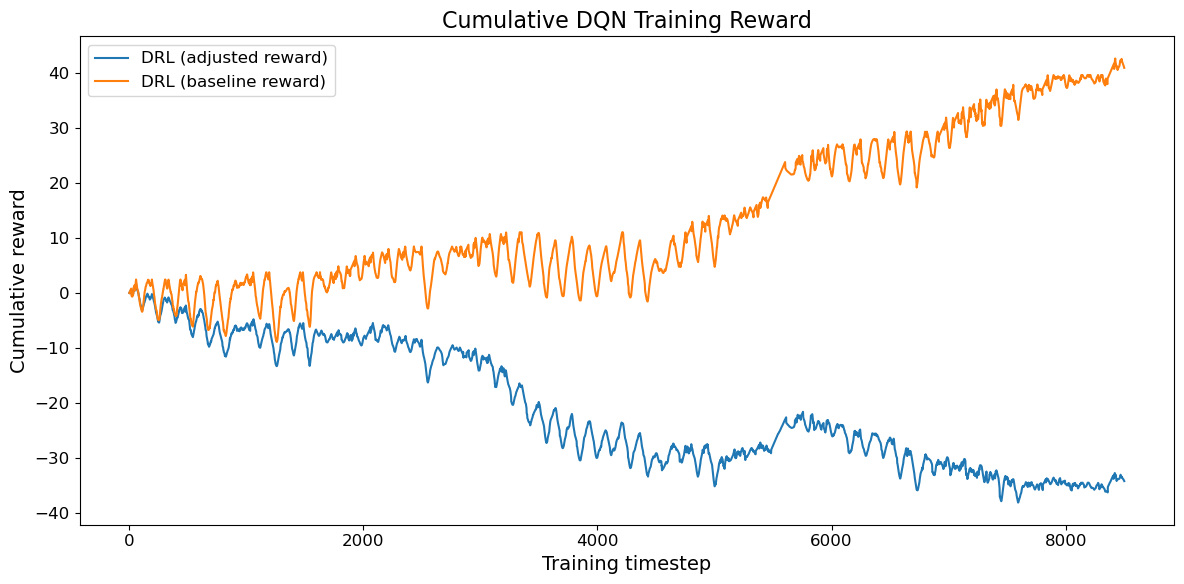

In [234]:
fig, ax = plt.subplots(figsize=(12, 6))
for source, subset in training_data.groupby("source"):
    ax.plot(
        subset["timesteps"],
        subset["cumulative_reward"],
        label=name_to_short_label.get(source, source),
    )

ax.set_xlabel("Training timestep")
ax.set_ylabel("Cumulative reward")
ax.set_title("Cumulative DQN Training Reward")
ax.legend()
plt.tight_layout()
plt.show()